DATA PREPROCESSING

In [53]:
# DEFINITIONS AND IMPORTING

import pandas as pd
import numpy as np
import scipy.stats as stats
import sklearn.linear_model as lm
import sklearn.ensemble as se
import sklearn.metrics as sm
import sklearn.model_selection as sms
import sklearn.neighbors as sn
import xgboost as xgb
import matplotlib.pyplot as pyplt
import boruta as bt
import catboost as cb
import optuna
from IPython.display import clear_output
import warnings
import pickle
import os
import shap
warnings.simplefilter('ignore')
np.random.seed(42)

np.int = np.int64
np.float = np.float64
np.bool = np.bool_

SKF = sms.StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

clear_output()

In [54]:
# FILTER LOADING

stat_sel_icc = pd.read_pickle("databases/statistically_selected_features_icc.pkl")
stat_sel_pval1 = pd.read_pickle("databases/statistically_selected_features_pval1.pkl")
stat_sel_pval2 = pd.read_pickle("databases/statistically_selected_features_pval2.pkl")
stat_sel_pval3 = pd.read_pickle("databases/statistically_selected_features_pval3.pkl")

filt1 = [stat_sel_pval1, stat_sel_icc]
filt2 = [stat_sel_pval2, stat_sel_icc]
filt3 = [stat_sel_pval3, stat_sel_icc]

# DATA LOADING

derived_keys = ["native", "1_pc", "2_pc", "3_pc", "4_pc", "5_pc"]

def process_data(data_X, feature_filters):

    load_X = data_X

    df_derived = pd.concat([load_X[key] for key in derived_keys])
    load_X["feat_mean"] = df_derived.groupby(df_derived.index).mean()
    load_X["feat_max_diff"] = df_derived.groupby(df_derived.index).max() - df_derived.groupby(df_derived.index).min()
    load_X["feat_std"] = df_derived.groupby(df_derived.index).std()
    load_X["feat_max"] = df_derived.groupby(df_derived.index).max()
    load_X["feat_min"] = df_derived.groupby(df_derived.index).min()

    for i in load_X.keys():
        load_X[i].sort_index(inplace=True)
        load_X[i].reset_index(inplace=True)
        load_X[i].drop("index_list", axis=1, inplace=True)
        if(feature_filters!=None):
            temp_list = list(feature_filters[0][i])
            for j in feature_filters:
                temp_list = list(set(temp_list).intersection(list(j[i])))
            load_X[i] = load_X[i][temp_list]
    
    for i in load_X.keys():
        load_X[i].columns += f"_{i}"
    
    return_X = pd.concat(load_X.values(), axis=1)
    return return_X

db_1 = pd.read_pickle("databases/database_1_X.pkl")
db_2 = pd.read_pickle("databases/database_2_X.pkl")

db1_index_list = []
for i in db_1["native"].index.values:
    db1_index_list.append(i[1:])
for i in db_1.keys():
    db_1[i]["index_list"] = db1_index_list
    db_1[i].set_index("index_list", inplace=True)

db2_index_list = []
for i in db_2["native"].index.values:
    db2_index_list.append(i[1:])
for i in db_2.keys():
    db_2[i]["index_list"] = db2_index_list
    db_2[i].set_index("index_list", inplace=True)

final_index_list = []
for i in db2_index_list:
    if(i in db1_index_list):
        final_index_list.append(i)

for i in db_1.keys():
    db_1[i] = db_1[i].loc[final_index_list]
    db_2[i] = db_2[i].loc[final_index_list]

db_3 = {}
key_list = list(db_1.keys())
for i in key_list:
    db_3[i] = db_2[i] - db_1[i]

X_pre = process_data(db_1, filt1)
X_post = process_data(db_2, filt2)
X_delta = process_data(db_3, filt3)

db_y = pd.read_csv("databases/database_1_y.csv")
db_y.set_index("seg_name", inplace=True)
dby_index_list = []
for i in db_y.index.values:
    dby_index_list.append(i[1:])
db_y["index_list"] = dby_index_list
db_y.set_index("index_list", inplace=True)

db_y = db_y.loc[final_index_list]
db_y.sort_index(inplace=True)
db_y.reset_index(inplace=True)
db_y.drop("index_list", axis=1, inplace=True)

y = db_y

db_clinical = pd.read_excel("databases/database_clinical.xlsx")
db_clinical.set_index("pre", inplace=True)
db_clinical_index_list = []
for i in db_clinical.index.values:
    db_clinical_index_list.append((str(i) + ".nii.gz")[1:])
db_clinical["index_list"] = db_clinical_index_list
db_clinical.set_index("index_list", inplace=True)

db_clinical = db_clinical.loc[final_index_list]
db_clinical.sort_index(inplace=True)
db_clinical.reset_index(inplace=True)
db_clinical.drop("index_list", axis=1, inplace=True)

clinical = db_clinical

print(f"Feature counts pre = {len(list(X_pre.columns))}")
print(f"Feature counts post = {len(list(X_post.columns))}")
print(f"Feature counts delta = {len(list(X_delta.columns))}")

Feature counts pre = 2021
Feature counts post = 6840
Feature counts delta = 1404


In [55]:
# FEATURE SELECTION

feature_sel = {}

def boruta_feature_selection(input_X, input_y):
    
    arr_X = input_X.to_numpy()
    arr_y = input_y.to_numpy()

    fs_model = xgb.XGBClassifier(random_state=42)
    fs_boruta = bt.BorutaPy(fs_model, n_estimators="auto", verbose=2, random_state=42, perc=80)
    fs_boruta.fit(arr_X, arr_y)  

    return list(input_X.columns[fs_boruta.support_ | fs_boruta.support_weak_])

feature_file = f"features/selected_features_3-tier_pre.pkl"
if(os.path.isfile(feature_file) == False):
    selected_features = boruta_feature_selection(X_pre, y)
    output = open(feature_file, "wb")
    pickle.dump(selected_features, output)
    output.close()

selected_features = pd.read_pickle(feature_file)
X_pre = X_pre[selected_features]

feature_file = f"features/selected_features_3-tier_post.pkl"
if(os.path.isfile(feature_file) == False):
    selected_features = boruta_feature_selection(X_post, y)
    output = open(feature_file, "wb")
    pickle.dump(selected_features, output)
    output.close()

selected_features = pd.read_pickle(feature_file)
X_post = X_post[selected_features]

feature_file = f"features/selected_features_3-tier_delta.pkl"
if(os.path.isfile(feature_file) == False):
    selected_features = boruta_feature_selection(X_delta, y)
    output = open(feature_file, "wb")
    pickle.dump(selected_features, output)
    output.close()

selected_features = pd.read_pickle(feature_file)
X_delta = X_delta[selected_features]

clear_output()

print(f"Feature counts pre = {len(list(X_pre.columns))}")
print(f"Feature counts post = {len(list(X_post.columns))}")
print(f"Feature counts delta = {len(list(X_delta.columns))}")

Feature counts pre = 16
Feature counts post = 16
Feature counts delta = 51


In [56]:
# DATABASE SPLIT

train_X = {}
test_X = {}

X_temp_train, X_temp_test, y_temp_train, y_temp_test = sms.train_test_split(X_delta, y, stratify=y, test_size=0.2, random_state=42)
train_indices = list(y_temp_train.index.values)
test_indices = list(y_temp_test.index.values)
train_indices.sort()
test_indices.sort()

train_X["pre"] = X_pre.drop(test_indices, axis=0)
test_X["pre"] = X_pre.drop(train_indices, axis=0)
train_X["post"] = X_post.drop(test_indices, axis=0)
test_X["post"] = X_post.drop(train_indices, axis=0)
train_X["delta"] = X_delta.drop(test_indices, axis=0)
test_X["delta"] = X_delta.drop(train_indices, axis=0)

train_y = y.drop(test_indices, axis=0)
test_y = y.drop(train_indices, axis=0)

train_clinical = clinical.drop(test_indices, axis=0)
test_clinical = clinical.drop(train_indices, axis=0)

PIPELINE FUNCTIONS

In [57]:
cross_validation = pd.DataFrame(columns=["Model", "Accuracy", "Accuracy 95-CI", "F1", "F1 95-CI", "ROC-AUC", "ROC-AUC 95-CI"])

def return_parametrized(model_name, load):
    if(model_name=="RandomForestClassifier"):
        return se.RandomForestClassifier(**load)
    elif(model_name=="XGBoostClassifier"):
        return xgb.XGBClassifier(**load)
    elif(model_name=="CatBoostClassifier"):
        return cb.CatBoostClassifier(**load)
    elif(model_name=="LassoLogistic"):
        return lm.LogisticRegression(**load)
    else:
        return None
    
def RandomForestClassifier_Lib(trial):
    return {"n_estimators" : trial.suggest_int("n_estimators", 10, 2000, log=True),
            "max_depth" : trial.suggest_int("max_depth", 1, 20),
            "min_samples_split" : trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf" : trial.suggest_int("min_samples_leaf", 1, 20),
            "max_leaf_nodes" : trial.suggest_int("max_leaf_nodes", 2, 20),
            "min_impurity_decrease" : trial.suggest_float("min_impurity_decrease", 0, 0.1),
            "min_weight_fraction_leaf" : trial.suggest_float("min_weight_fraction_leaf", 0, 0.5),
            "random_state" : trial.suggest_categorical("random_state", [42]),
            "max_features" : trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "bootstrap" : trial.suggest_categorical("bootstrap", [True, False])}

def XGBoostClassifier_Lib(trial):
    return {"booster" : trial.suggest_categorical("booster", ["gbtree"]),
            "n_estimators" : trial.suggest_int("n_estimators", 10, 2000, log=True),
            "max_depth" : trial.suggest_int("max_depth", 1, 10),
            "max_delta_step" : trial.suggest_float("max_delta_step", 0, 10),
            "learning_rate" : trial.suggest_float("learning_rate", 0.01, 1.0, log=True),
            "alpha" : trial.suggest_float("alpha", 0.01, 100, log=True),
            "gamma" : trial.suggest_float("gamma", 0.01, 1, log=True),
            "lambda" : trial.suggest_float("lambda", 0.01, 100, log=True),
            "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.1, 1),
            "colsample_bylevel" : trial.suggest_float("colsample_bytree", 0.1, 1),
            "random_state" : trial.suggest_categorical("random_state", [42])}

def CatBoostClassifier_Lib(trial):
    return {"iterations" : trial.suggest_int("iterations", 50, 500, log=True),
            "learning_rate" : trial.suggest_float("learning_rate", 0.005, 1, log=True),
            "depth" : trial.suggest_int("depth", 1, 10),
            "min_data_in_leaf" : trial.suggest_int("min_data_in_leaf", 1, 150),
            "random_state" : trial.suggest_categorical("random_state", [42]),
            "subsample" : trial.suggest_float("subsample", 0.5, 1),
            "colsample_bylevel" : trial.suggest_float("colsample_bylevel", 0.1, 1)} 

def LassoLogistic_Lib(trial):
    return {"penalty" : trial.suggest_categorical("penalty", ["l1"]),
            "random_state" : trial.suggest_categorical("random_state", [42]),
            "solver" : trial.suggest_categorical("solver", ["liblinear", "saga"]),
            "max_iter" : trial.suggest_int("max_iter", 100, 3000),
            "C" : trial.suggest_float("C", 0.01, 1)}

def return_CI(data):
    data = np.array(data)
    mean = np.mean(data)
    sem = stats.sem(data)
    ci = stats.t.interval(0.95, len(data) - 1, loc=mean, scale=sem)
    return ci

def return_for_optuna(trial, model_name): 
    if(model_name=="RandomForestClassifier"):
        return se.RandomForestClassifier(**(RandomForestClassifier_Lib(trial)))
    elif(model_name=="XGBoostClassifier"):
        return xgb.XGBClassifier(**(XGBoostClassifier_Lib(trial)))
    elif(model_name=="CatBoostClassifier"):
        return cb.CatBoostClassifier(**(CatBoostClassifier_Lib(trial)))
    elif(model_name=="LassoLogistic"):
        return lm.LogisticRegression(**(LassoLogistic_Lib(trial)))
    else:
        return None

def hyperparameter_optimization(model_name, input_X, input_y):

    def objective(trial):

        model = return_for_optuna(trial, model_name)
        score_list = sms.cross_validate(model, input_X, input_y, cv=SKF, scoring=("accuracy", "f1", "roc_auc"), n_jobs=-1)
        roc_auc = np.mean(score_list["test_roc_auc"])
        accuracy = np.mean(score_list["test_accuracy"])
        f1 = np.mean(score_list["test_f1"])

        return (5*roc_auc + accuracy + f1)
    
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=100, n_jobs=-1)
    return study.best_params

def optimize_fit(model_name, input_X, input_y, database_name):

    param_file = f"hyperparameters/hyperparameters_3-tier_{database_name}_{model_name}.pkl"
    if(os.path.isfile(param_file) == False):
        hyperparameters = hyperparameter_optimization(model_name, input_X, input_y)
        output = open(param_file, "wb")
        pickle.dump(hyperparameters, output)
        output.close()  
    hyperparameters = pd.read_pickle(param_file)
    model = return_parametrized(model_name, hyperparameters)

    score_list = sms.cross_validate(model, input_X, input_y, cv=SKF, scoring=("accuracy", "f1", "roc_auc"), n_jobs=-1)

    roc_auc = np.mean(score_list["test_roc_auc"])
    roc_auc_ci = return_CI(score_list["test_roc_auc"])
    accuracy = np.mean(score_list["test_accuracy"])
    accuracy_ci = return_CI(score_list["test_accuracy"])
    f1 = np.mean(score_list["test_f1"])
    f1_ci = return_CI(score_list["test_f1"])

    cross_validation.loc[len(cross_validation.index)] = [model_name, accuracy, accuracy_ci, f1, f1_ci, roc_auc, roc_auc_ci]

    model.fit(input_X, input_y)

    clear_output()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(input_X)

    if(model_name=="RandomForestClassifier"):
        shap.plots.beeswarm(shap_values[:,:,1], max_display=15)
    else:
        shap.plots.beeswarm(shap_values, max_display=15)
    
    return model

def pipeline(model_name, database_name):

    model = optimize_fit(model_name, train_X[database_name], train_y, database_name)    
    pred_y = model.predict(test_X[database_name])
    prob_y = model.predict_proba(test_X[database_name])[:, 1]
    train_prob_y = model.predict_proba(train_X[database_name])[:, 1]
    
    model_file = f"models/3-tier_{database_name}_{model_name}.pkl"
    output = open(model_file, "wb")
    pickle.dump(model, output)
    output.close()  

    return pred_y, prob_y, train_prob_y

MODELLING & PREDICTION EXTRACTION

In [58]:
pred = {}
prob = {}
train_prob = {}
models = ["CatBoostClassifier-PRE", "RandomForestClassifier-POST", "XGBoostClassifier-DELTA", "Stacking (no clinical)", "Stacking (with clinical)"]

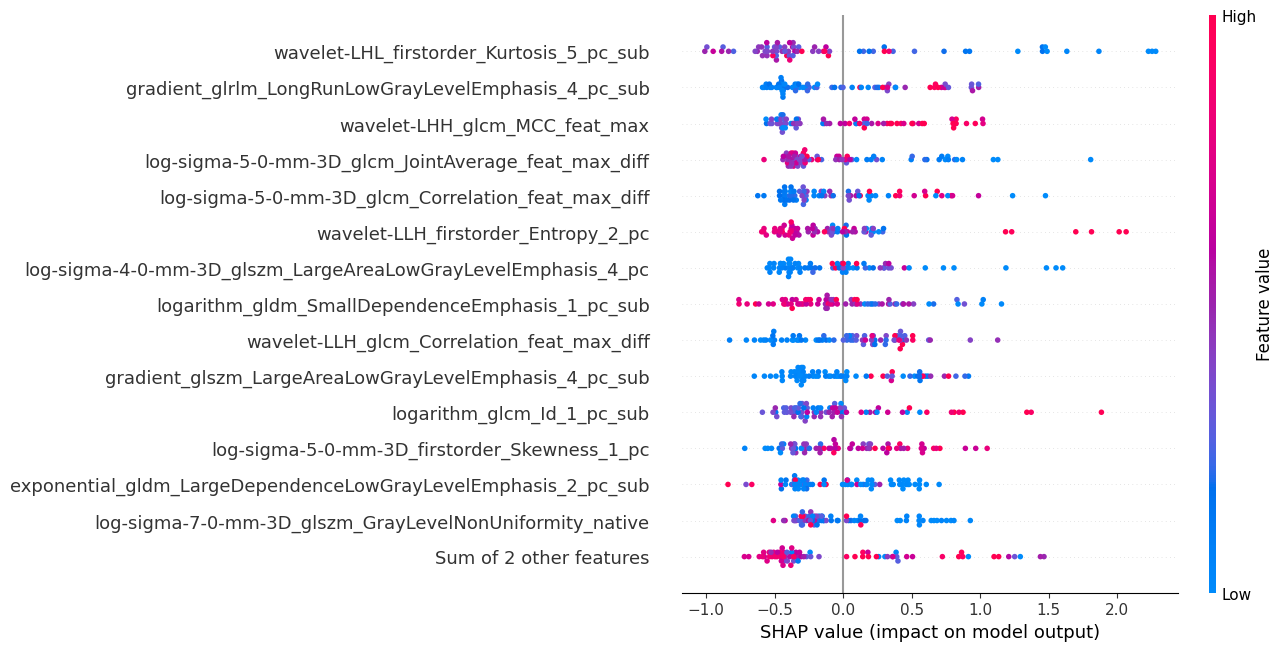

In [59]:
pred["CatBoostClassifier-PRE"], prob["CatBoostClassifier-PRE"], train_prob["CatBoostClassifier-PRE"] = pipeline("CatBoostClassifier", "pre")

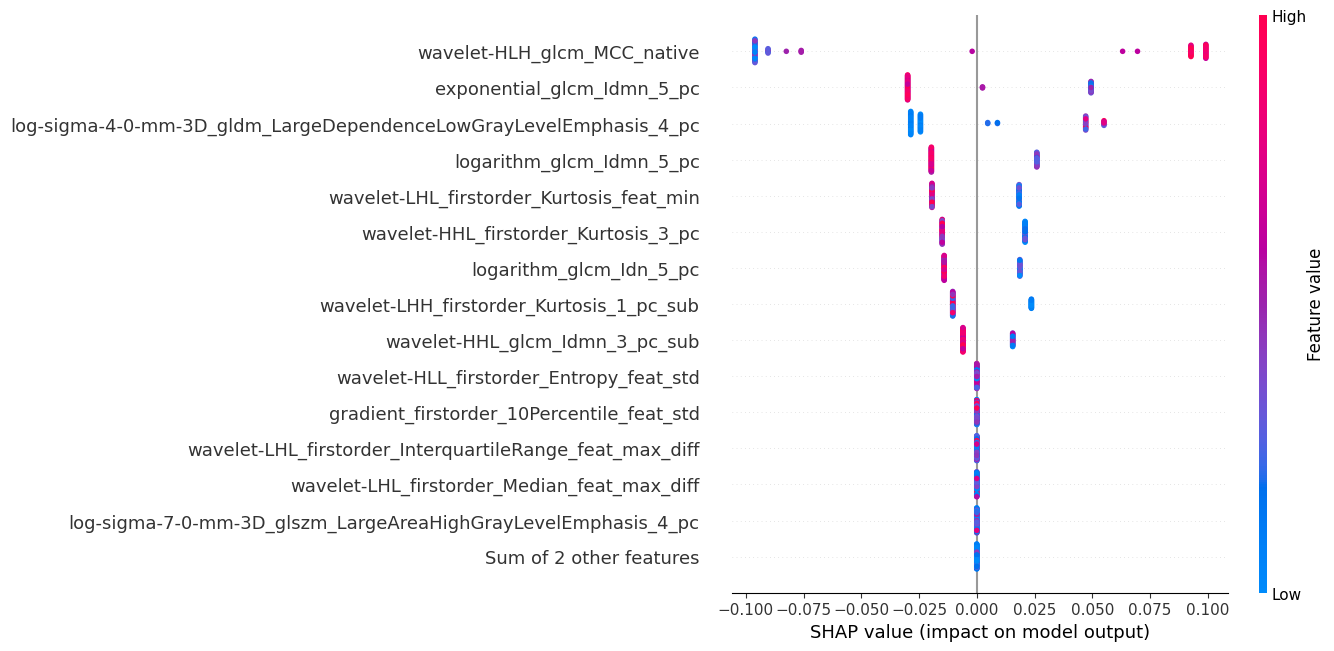

In [60]:
pred["RandomForestClassifier-POST"], prob["RandomForestClassifier-POST"], train_prob["RandomForestClassifier-POST"] = pipeline("RandomForestClassifier", "post")

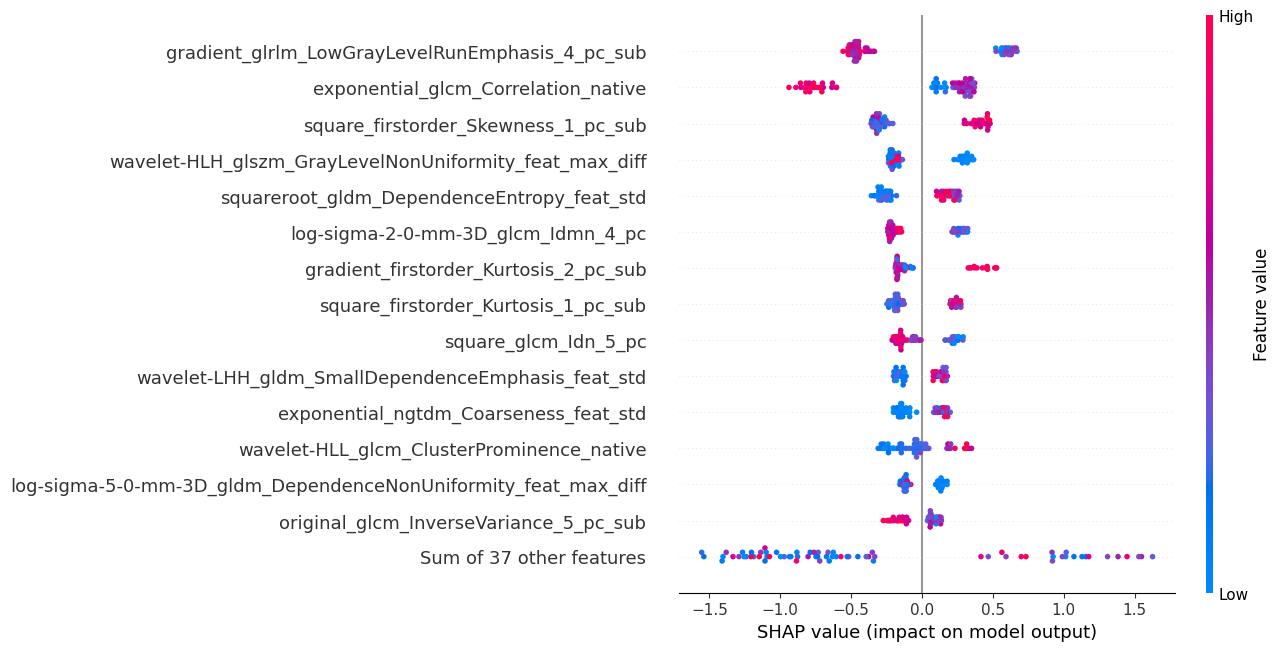

In [61]:
pred["XGBoostClassifier-DELTA"], prob["XGBoostClassifier-DELTA"], train_prob["XGBoostClassifier-DELTA"] = pipeline("XGBoostClassifier", "delta")

In [62]:
stacking_NO_train = pd.DataFrame(columns=["CatBoostClassifier-PRE", "RandomForestClassifier-POST", "XGBoostClassifier-DELTA"])
stacking_NO_test = pd.DataFrame(columns=["CatBoostClassifier-PRE", "RandomForestClassifier-POST", "XGBoostClassifier-DELTA"])

for i in ["CatBoostClassifier-PRE", "RandomForestClassifier-POST", "XGBoostClassifier-DELTA"]:
    stacking_NO_train[i] = train_prob[i]
    stacking_NO_test[i] = prob[i]

train_clinical.reset_index(inplace=True)
test_clinical.reset_index(inplace=True)
train_clinical.drop("index", axis=1, inplace=True)
test_clinical.drop("index", axis=1, inplace=True)

stacking_W_train = pd.concat([stacking_NO_train, train_clinical], axis=1)
stacking_W_test = pd.concat([stacking_NO_test, test_clinical], axis=1)

train_X["stacking_NO"] = stacking_NO_train
test_X["stacking_NO"] = stacking_NO_test
train_X["stacking_W"] = stacking_W_train
test_X["stacking_W"] = stacking_W_test

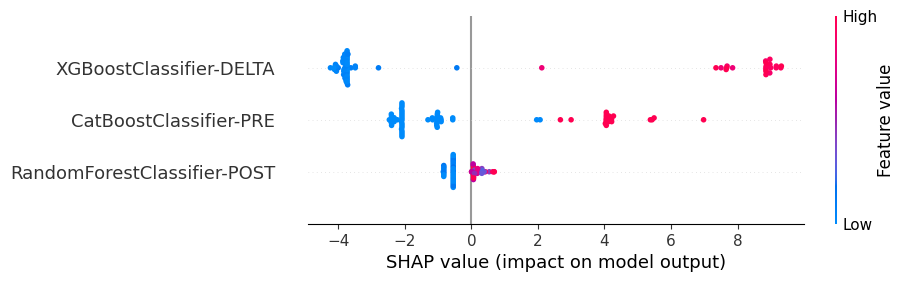

In [63]:
pred["Stacking (no clinical)"], prob["Stacking (no clinical)"], _ = pipeline("CatBoostClassifier", "stacking_NO")

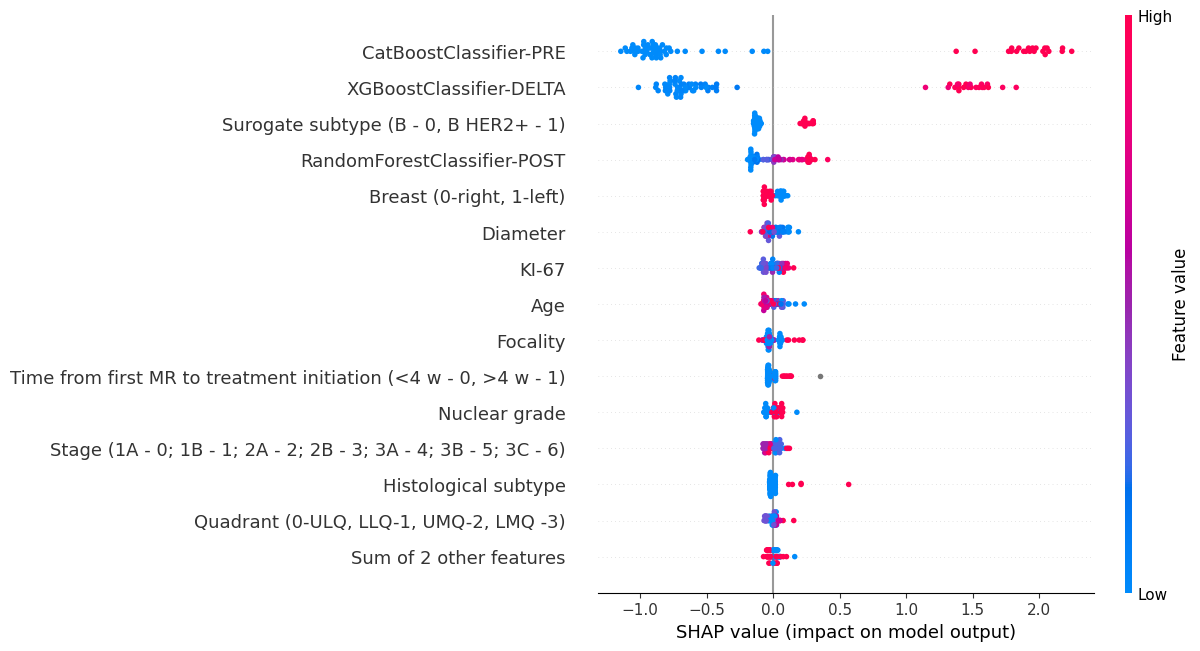

In [64]:
pred["Stacking (with clinical)"], prob["Stacking (with clinical)"], _ = pipeline("CatBoostClassifier", "stacking_W")

PREDICTION VALIDATION

In [65]:
results = pd.DataFrame(index=[1, 2, 3, 4, 5], columns=["Model", "Accuracy", "Sensitivity (Recall-1)", "Specificity (Recall-0)", "F1", "PR-AUC", "ROC-AUC"])
results["Model"] = models

In [66]:
# ACCURACY, SENSITIVITY, SPECIFICITY, F1

accuracy_list = []
sensitivity_list = []
specificity_list = []
f1_list = []

for i in models:
    accuracy_list.append(sm.accuracy_score(test_y, pred[i]))
    sensitivity_list.append(sm.recall_score(test_y, pred[i], pos_label=1))
    specificity_list.append(sm.recall_score(test_y, pred[i], pos_label=0))
    f1_list.append(sm.f1_score(test_y, pred[i]))

results["Accuracy"] = accuracy_list
results["Sensitivity (Recall-1)"] = sensitivity_list
results["Specificity (Recall-0)"] = specificity_list
results["F1"] = f1_list

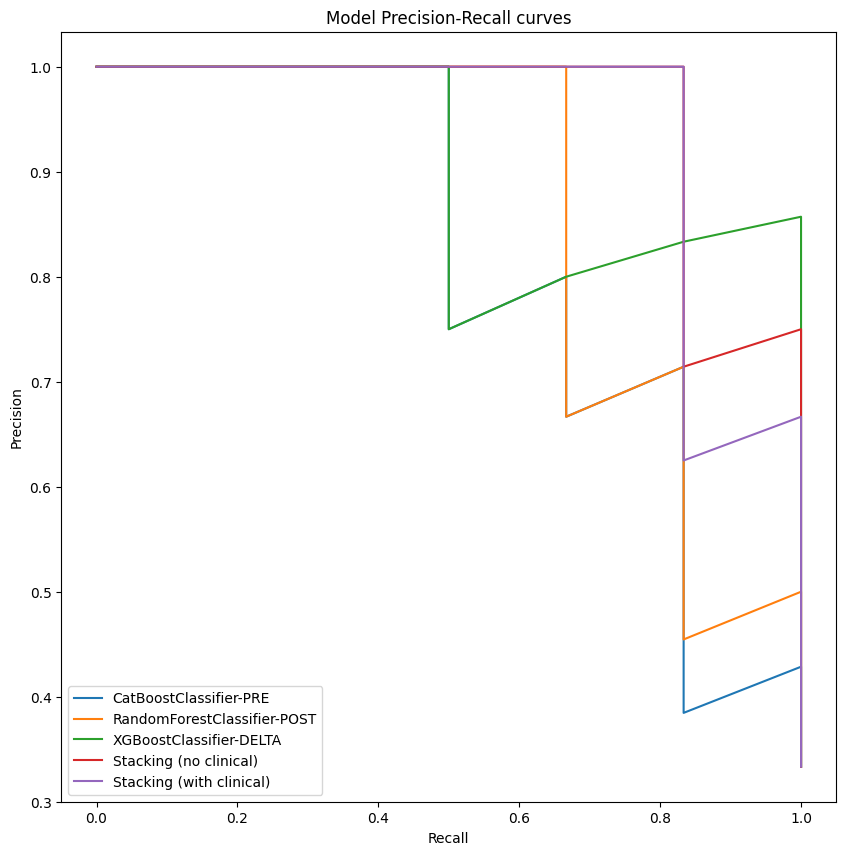

In [67]:
# PRECISION-RECALL CURVE

pr_auc_list = []
pyplt.figure(figsize=(10, 10))

for i in models:
    precision, recall, thresholds = sm.precision_recall_curve(test_y, prob[i])
    pr_auc_list.append(sm.auc(recall, precision))
    pyplt.plot(recall, precision, label=i)

pyplt.xlabel("Recall")
pyplt.ylabel("Precision")
pyplt.title("Model Precision-Recall curves")
pyplt.legend(loc = "lower left")
pyplt.show()

results["PR-AUC"] = pr_auc_list

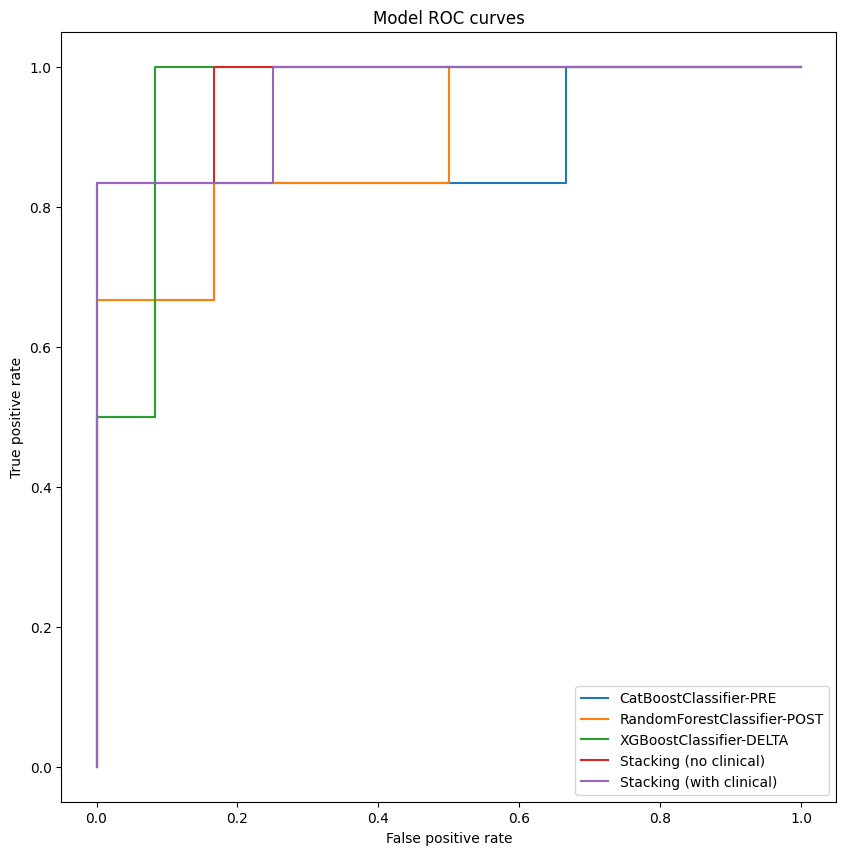

In [68]:
# ROC CURVE

roc_auc_list = []
pyplt.figure(figsize=(10, 10))

for i in models:
    fpr, tpr, thresholds = sm.roc_curve(test_y, prob[i])
    roc_auc_list.append(sm.roc_auc_score(test_y, prob[i]))
    pyplt.plot(fpr, tpr, label=i)

pyplt.xlabel("False positive rate")
pyplt.ylabel("True positive rate")
pyplt.title("Model ROC curves")
pyplt.legend(loc = "lower right")
pyplt.show()

results["ROC-AUC"] = roc_auc_list

DATA SAVE

In [69]:
# RESULT SAVE

print(results)
results.to_csv("results/3-tier_results.csv")
cross_validation.to_csv("results/3-tier_cross_validation.csv")

                         Model  Accuracy  Sensitivity (Recall-1)  \
1       CatBoostClassifier-PRE  0.777778                0.833333   
2  RandomForestClassifier-POST  0.888889                0.666667   
3      XGBoostClassifier-DELTA  0.833333                0.500000   
4       Stacking (no clinical)  0.888889                0.833333   
5     Stacking (with clinical)  0.944444                0.833333   

   Specificity (Recall-0)        F1    PR-AUC   ROC-AUC  
1                0.750000  0.714286  0.812012  0.847222  
2                1.000000  0.800000  0.861291  0.888889  
3                1.000000  0.666667  0.906151  0.958333  
4                0.916667  0.833333  0.955357  0.972222  
5                1.000000  0.909091  0.940972  0.958333  
